In [3]:
import numpy as np # 导入NumPy数学工具箱
import pandas as pd # 导入Pandas数据处理工具箱
df_heart = pd.read_csv("./heart.csv")  # 读取文件
df_heart.head() # 显示前5行数据

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df_heart.target.value_counts() # 输出分类值，及各个类别数目

,count
target,
1,165
0,138


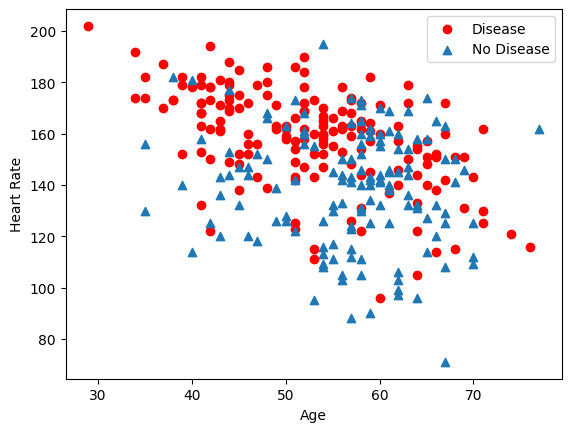

In [5]:
import matplotlib.pyplot as plt # 导入绘图工具
# 以年龄+最大心率作为输入，查看分类结果散点图
plt.scatter(x=df_heart.age[df_heart.target==1],
            y=df_heart.thalach[(df_heart.target==1)], c="red")
plt.scatter(x=df_heart.age[df_heart.target==0],
            y=df_heart.thalach[(df_heart.target==0)], marker='^')
plt.legend(["Disease", "No Disease"]) # 显示图例
plt.xlabel("Age") # X轴-Age
plt.ylabel("Heart Rate") # Y轴-Heart Rate
plt.show() # 显示散点图

In [6]:
X = df_heart.drop(['target'], axis = 1) # 构建特征集
y = df_heart.target.values # 构建标签集
y = y.reshape(-1,1) # -1是	相对索引，等价于len(y)
print("张量X的形状:", X.shape)
print("张量X的形状:", y.shape)

张量X的形状: (303, 13)
张量X的形状: (303, 1)


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

In [8]:
from sklearn.preprocessing import MinMaxScaler # 导入数据缩放器
scaler = MinMaxScaler() # 选择归一化数据缩放器，MinMaxScaler
X_train = scaler.fit_transform(X_train) # 特征归一化 训练集fit_transform
X_test = scaler.transform(X_test) # 特征归一化 测试集transform

In [9]:
# 首先定义一个Sigmoid函数，输入Z，返回y'
def sigmoid(z):
    y_hat = 1/(1+ np.exp(-z))
    return y_hat

In [10]:
# 然后定义损失函数
def loss_function(X,y,w,b):
    y_hat = sigmoid(np.dot(X,w) + b) # Sigmoid逻辑函数 + 线性函数(wX+b)得到y'
    loss = -(y*np.log(y_hat) + (1-y)*np.log(1-y_hat)) # 计算损失
    cost = np.sum(loss) / X.shape[0]  # 整个数据集平均损失
    return cost # 返回整个数据集平均损失

In [11]:
# 然后构建梯度下降的函数
def gradient_descent(X,y,w,b,lr,iter) : #定义逻辑回归梯度下降函数
    l_history = np.zeros(iter) # 初始化记录梯度下降过程中误差值(损失)的数组
    w_history = np.zeros((iter,w.shape[0],w.shape[1])) # 初始化权重记录的数组
    b_history = np.zeros(iter) # 初始化记录梯度下降过程中偏置的数组
    for i in range(iter): #进行机器训练的迭代
        y_hat = sigmoid(np.dot(X,w) + b) #Sigmoid逻辑函数+线性函数(wX+b)得到y'
        derivative_w = np.dot(X.T,((y_hat-y)))/X.shape[0]  # 给权重向量求导
        derivative_b = np.sum(y_hat-y)/X.shape[0] # 给偏置求导
        w = w - lr * derivative_w # 更新权重向量，lr即学习速率alpha
        b = b - lr * derivative_b   # 更新偏置，lr即学习速率alpha
        l_history[i] =  loss_function(X,y,w,b) # 梯度下降过程中的损失
        print ("轮次", i+1 , "当前轮训练集损失：",l_history[i])
        w_history[i] = w # 梯度下降过程中权重的历史 请注意w_history和w的形状
        b_history[i] = b # 梯度下降过程中偏置的历史
    return l_history, w_history, b_history

In [15]:
def predict(X,w,b): # 定义预测函数
    z = np.dot(X,w) + b # 线性函数
    y_hat = sigmoid(z) # 逻辑函数转换
    y_pred = np.zeros((y_hat.shape[0],1)) # 初始化预测结果变量
    for i in range(y_hat.shape[0]):
        if y_hat[i,0] < 0.5:
            y_pred[i,0] = 0 # 如果预测概率小于0.5，输出分类0
        else:
            y_pred[i,0] = 1 # 如果预测概率大于0.5，输出分类1
    return y_pred # 返回预测分类的结果

In [12]:
def logistic_regression(X,y,w,b,lr,iter): # 定义逻辑回归模型
    l_history,w_history,b_history = gradient_descent(X,y,w,b,lr,iter)#梯度下降
    print("训练最终损失:", l_history[-1]) # 打印最终损失
    y_pred = predict(X,w_history[-1],b_history[-1]) # 进行预测
    traning_acc = 100 - np.mean(np.abs(y_pred - y_train))*100 # 计算准确率
    print("逻辑回归训练准确率: {:.2f}%".format(traning_acc))  # 打印准确率
    return l_history, w_history, b_history # 返回训练历史记录

In [13]:
#初始化参数
dimension = X.shape[1] # 这里的维度 len(X)是矩阵的行的数，维度是列的数目
weight = np.full((dimension,1),0.1) # 权重向量，向量一般是1D，但这里实际上创建了2D张量
bias = 0 # 偏置值
#初始化超参数
alpha = 1 # 学习速率
iterations = 500 # 迭代次数

In [16]:
# 用逻辑回归函数训练机器
loss_history, weight_history, bias_history =  \
            logistic_regression(X_train,y_train,weight,bias,alpha,iterations)

轮次 1 当前轮训练集损失： 0.669306577359221
轮次 2 当前轮训练集损失： 0.6436287734562866
轮次 3 当前轮训练集损失： 0.621257883894751
轮次 4 当前轮训练集损失： 0.6016424333420419
轮次 5 当前轮训练集损失： 0.5843880887531875
轮次 6 当前轮训练集损失： 0.5691551737456341
轮次 7 当前轮训练集损失： 0.5556535376820843
轮次 8 当前轮训练集损失： 0.5436368159227767
轮次 9 当前轮训练集损失： 0.5328965486716621
轮次 10 当前轮训练集损失： 0.5232566243869441
轮次 11 当前轮训练集损失： 0.5145682777884659
轮次 12 当前轮训练集损失： 0.5067057232714539
轮次 13 当前轮训练集损失： 0.4995624189184545
轮次 14 当前轮训练集损失： 0.49304791219547567
轮次 15 当前轮训练集损失： 0.48708519967298275
轮次 16 当前轮训练集损失： 0.4816085288888676
轮次 17 当前轮训练集损失： 0.476561573914217
轮次 18 当前轮训练集损失： 0.4718959231718517
轮次 19 当前轮训练集损失： 0.46756982623790305
轮次 20 当前轮训练集损失： 0.46354715446685874
轮次 21 当前轮训练集损失： 0.45979653770881607
轮次 22 当前轮训练集损失： 0.45629064589269824
轮次 23 当前轮训练集损失： 0.45300558978988925
轮次 24 当前轮训练集损失： 0.4499204199083981
轮次 25 当前轮训练集损失： 0.4470167063007529
轮次 26 当前轮训练集损失： 0.44427818521401824
轮次 27 当前轮训练集损失： 0.44169046107843574
轮次 28 当前轮训练集损失： 0.43924075442203775
轮次 29 当前轮训练集损失： 0.4369

In [17]:
y_pred = predict(X_test,weight_history[-1],bias_history[-1]) # 预测测试集
testing_acc = 100 - np.mean(np.abs(y_pred - y_test))*100 # 计算准确率
print("逻辑回归测试准确率: {:.2f}%".format(testing_acc))

逻辑回归测试准确率: 83.61%


In [18]:
print ("逻辑回归预测分类值:",predict(X_test,weight_history[-1],bias_history[-1]))

逻辑回归预测分类值: [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]]


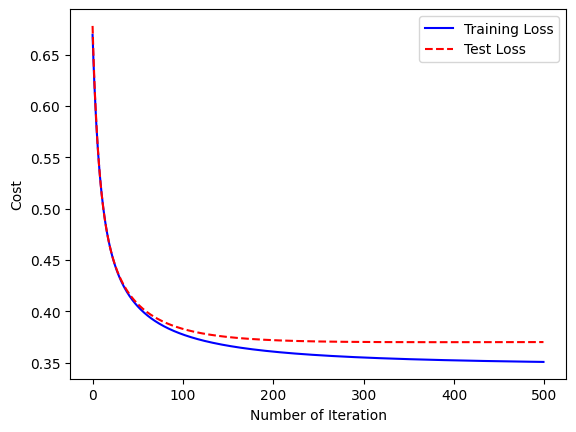

In [19]:
loss_history_test = np.zeros(iterations) # 初始化历史损失
for i in range(iterations): #求训练过程中不同参数带来的测试集损失
    loss_history_test[i] = loss_function(X_test,y_test,
                                         weight_history[i],bias_history[i])
index = np.arange(0,iterations,1)
plt.plot(index, loss_history,c='blue',linestyle='solid')
plt.plot(index, loss_history_test,c='red',linestyle='dashed')
plt.legend(["Training Loss", "Test Loss"])
plt.xlabel("Number of Iteration")
plt.ylabel("Cost")
plt.show() # 同时显示显示训练集和测试集损失曲线

In [21]:
# 把3个文本型变量转换为哑变量
a = pd.get_dummies(df_heart['cp'], prefix = "cp")
b = pd.get_dummies(df_heart['thal'], prefix = "thal")
c = pd.get_dummies(df_heart['slope'], prefix = "slope")
# 把哑变量添加进dataframe
frames = [df_heart, a, b, c]
df_heart = pd.concat(frames, axis = 1)
df_heart = df_heart.drop(columns = ['cp', 'thal', 'slope'])
df_heart.head() # 显示新的dataframe

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,63,1,145,233,1,0,150,0,2.3,0,...,False,False,True,False,True,False,False,True,False,False
1,37,1,130,250,0,1,187,0,3.5,0,...,False,True,False,False,False,True,False,True,False,False
2,41,0,130,204,0,0,172,0,1.4,0,...,True,False,False,False,False,True,False,False,False,True
3,56,1,120,236,0,1,178,0,0.8,0,...,True,False,False,False,False,True,False,False,False,True
4,57,0,120,354,0,1,163,1,0.6,0,...,False,False,False,False,False,True,False,False,False,True


In [22]:
from sklearn.linear_model import LogisticRegression #导入逻辑回归模型
lr = LogisticRegression() # lr,就代表是逻辑回归模型
lr.fit(X_train,y_train) # fit,就相当于是梯度下降
print("SK-learn逻辑回归测试准确率{:.2f}%".format(lr.score(X_test,y_test)*100))

SK-learn逻辑回归测试准确率81.97%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
